
# 🏞️ Random Forest Regressor vs ExtraTrees

Aquest notebook mostra un exemple d'us del Model **Random Forest Regressor**. Una de les estratègies d'*Ensemble Models*. Concretament Random Forest utilitza l'estratègia de **Bagging** o **Bootstrap Aggregating**

---

## 🎯 Objectius
- Veure un exemple d'ús d'un Random Forest Regressor
- Veure la diferència entre un Decision Tree


##  🏠 Boston Housing

Volem predir la variable MEDV. valor mijtà de les vivendes.

En el conjunt de dades tenim:
- **CRIM**: taxa de delinqüència per càpita per ciutat.
- **ZN**: proporció de sòl residencial dividit per a segments de més de 25.000 peus quadrats.
- **INDUS**: proporció de superfície comercial no minorista per ciutat.
- **CHAS**: variable binària sobre el riu Charles (= 1 si la zona limita amb el riu; 0 en cas contrari).
- **NOX**: concentració d'òxids nítrics (parts de 10 milions).
- **RM**: nombre mitjà d'habitacions per habitatge.
- **EDAT**: proporció d'habitatges ocupats construïts abans del 1940.
- **DIS**: distància ponderada a cinc centres de treball a la ciutat de Boston.
- **RAD**: índex daccessibilitat a les autopistes radials.
- **TAX**: impost sobre béns immobles de valor íntegre per cada 10.000 dólars
- **PTRATIO**: ràtio alumnes-professor per ciutat.
- **LSTAT**: % de la població considerat de classe baixa.
- **MEDV** (variable a predir): valor mitjà dels habitatges en milers de $.

## ExtraTree Regressor

Pel mateix conjunt de dades de Boston Housing utilitzarem un Extra Tree Regressor i el compararem amb un RandomForestRegressor. utilitzarem el mateix número d'arbres.
Amb la comparativa mirarem el temps d'entrenament en cadascun d'ells.

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name boston exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=531
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=853

  warn(warning_msg)



=== Random Forest ===
R²:    0.8409
RMSE:  3.34

=== Extra Trees ===
R²:    0.8605
RMSE:  3.13

Temps d'entrenament:
Random Forest: 0.422 s
Extra Trees:   0.244 s


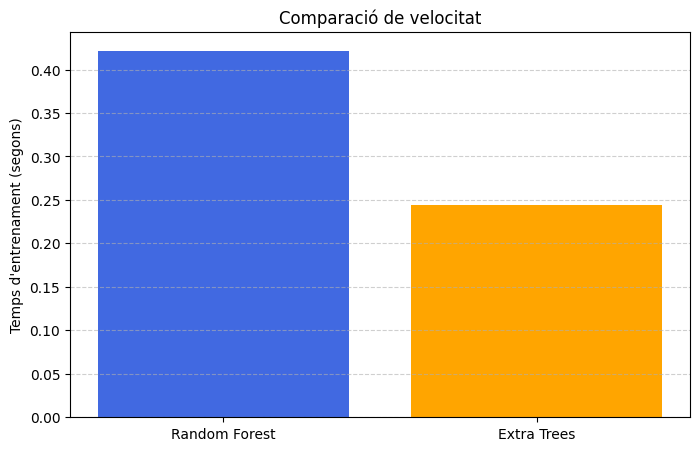

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor
from sklearn.metrics import mean_squared_error,root_mean_squared_error,r2_score


# Load the Boston Housing dataset
# --------------------------
boston = fetch_openml(name='boston')

df = boston['data']
df['MEDV'] = boston['target']

# Dividim el conjunt de dades train/test
# --------------------------
X_train, X_test, y_train, y_test = train_test_split(
                                        df.drop(columns="MEDV"),
                                        df['MEDV'],
                                        test_size = 0.25,
                                        random_state = 42
                                    )

# Definim els dos models
# max_depth=None, max_features=5, n_estimators=75
# --------------------------
rf = RandomForestRegressor(
    n_estimators=75,
    bootstrap=True, # Valor per defecte
    max_depth=None,
    max_features=5,
    random_state=42,
    n_jobs=-1
)

et = ExtraTreesRegressor(
    n_estimators=75,
    bootstrap=False, # Valor per defecte (ja tenim aleatorietat)
    max_depth=None,
    max_features=5,
    random_state=42,
    n_jobs=-1
)

# Entrenem i mesurem el temps i rendiment
# ---------------------------------------

start = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - start

start = time.time()
et.fit(X_train, y_train)
et_time = time.time() - start


# Avaluem els models
# ------------------

models = {'Random Forest': rf, 'Extra Trees': et}

for name, model in models.items():
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    print(f"\n=== {name} ===")
    print(f"R²:    {r2:.4f}")
    print(f"RMSE:  {rmse:.2f}")

print("\nTemps d'entrenament:")
print(f"Random Forest: {rf_time:.3f} s")
print(f"Extra Trees:   {et_time:.3f} s")

# Gràfic comparatiu
# ---------------------
plt.figure(figsize=(8, 5))
plt.bar(['Random Forest', 'Extra Trees'], [rf_time, et_time], color=['royalblue', 'orange'])
plt.ylabel("Temps d'entrenament (segons)")
plt.title("Comparació de velocitat")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Exemple anterior, però utilitzant una validació creuada per comparar els resultats

Explicació dels passos
| Pas     | Què fa                                                                                                 |
| ------- | ------------------------------------------------------------------------------------------------------ |
| **1️⃣** | Obtenim el conjunt de dades de regressió. (hi ha comentat un exmpel de com generar dades sintètiques)                                          |
| **2️⃣** | Definim els dos models amb els mateixos hiperparàmetres principals (`n_estimators`, `random_state`).   |
| **3️⃣** | Preparem una estratègia de validació creuada de 5 particions amb `KFold`.                              |
| **4️⃣** | Fem validació creuada amb `cross_val_score`, que entrena i avalua el model 5 cops amb dades diferents. |
| **5️⃣** | Mostrem els valors de R² per cada fold i la seva mitjana i desviació estàndard.                        |
| **6️⃣** | Dibuixem un gràfic boxplot per comparar visualment el rendiment dels dos models.                       |


/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name boston exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=531
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=853

  warn(warning_msg)


=== Random Forest ===
Scores per fold: [0.882 0.867 0.877 0.914 0.846]
Mitjana R²: 0.8770 ± 0.0223

=== Extra Trees ===
Scores per fold: [0.875 0.895 0.879 0.928 0.863]
Mitjana R²: 0.8881 ± 0.0224


/tmp/ipython-input-3218770869.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rf_scores, et_scores], labels=["Random Forest", "Extra Trees"])


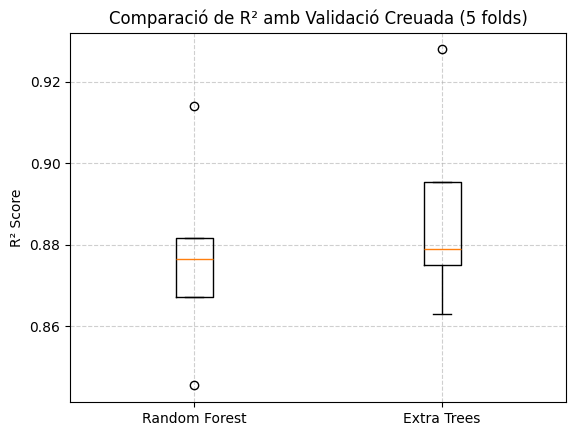

In [ ]:
# ================================================================
# Comparació amb VALIDACIÓ CREUADA de RandomForest vs ExtraTrees
# ================================================================

import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

# 1 Load Boston Dataset
# ----------------------------------------------------------------
boston = fetch_openml(name='boston')

df = boston['data']
df['MEDV'] = boston['target']
X = df.drop(columns="MEDV")
y = df['MEDV']

# Generem dades sintètiques
# ----------------------------------------------------------------
#X, y = make_regression(
#    n_samples=1500,
#    n_features=12,
#    noise=25,
#    random_state=42
#)

# max_depth=None, max_features=5, n_estimators=75
# 2 Definim els models
# ----------------------------------------------------------------
rf = RandomForestRegressor(
    n_estimators=75,
    max_features=5,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

et = ExtraTreesRegressor(
    n_estimators=75,
    max_features=5,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# 3 Definim l'estratègia de validació creuada
# ----------------------------------------------------------------
# 5 particions (5 folds)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 4 Avaluem amb cross-validation (mètrica = R²)
# ----------------------------------------------------------------
rf_scores = cross_val_score(rf, X, y, cv=cv, scoring='r2', n_jobs=-1)
et_scores = cross_val_score(et, X, y, cv=cv, scoring='r2', n_jobs=-1)

# 5 Mostrem resultats
# ----------------------------------------------------------------
print("=== Random Forest ===")
print(f"Scores per fold: {np.round(rf_scores, 3)}")
print(f"Mitjana R²: {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")

print("\n=== Extra Trees ===")
print(f"Scores per fold: {np.round(et_scores, 3)}")
print(f"Mitjana R²: {et_scores.mean():.4f} ± {et_scores.std():.4f}")

# 6 Comparació visual (opcional)
# ----------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

plt.boxplot([rf_scores, et_scores], labels=["Random Forest", "Extra Trees"])
plt.title("Comparació de R² amb Validació Creuada (5 folds)")
plt.ylabel("R² Score")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()
